In [7]:
# 1 Import Libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve
!pip install scorecardpy
import scorecardpy as sc

In [9]:
# 2 Load The Dataset
file_path = r"C:\Users\sagni\Downloads\Credit Risk Modelling\Credit Risk Modelling Data.csv"

df = pd.read_csv(file_path)

In [11]:
# 3 Explore the Data
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   clientid  2000 non-null   int64  
 1   income    2000 non-null   float64
 2   age       1997 non-null   float64
 3   loan      2000 non-null   float64
 4   default   2000 non-null   int64  
dtypes: float64(3), int64(2)
memory usage: 78.3 KB


In [13]:
# 4 basic Data Cleaning
df = df.drop_duplicates()
df.isnull().sum()
df = df.dropna()
#Convert target variable
df['default'] = df['default'].astype(int)

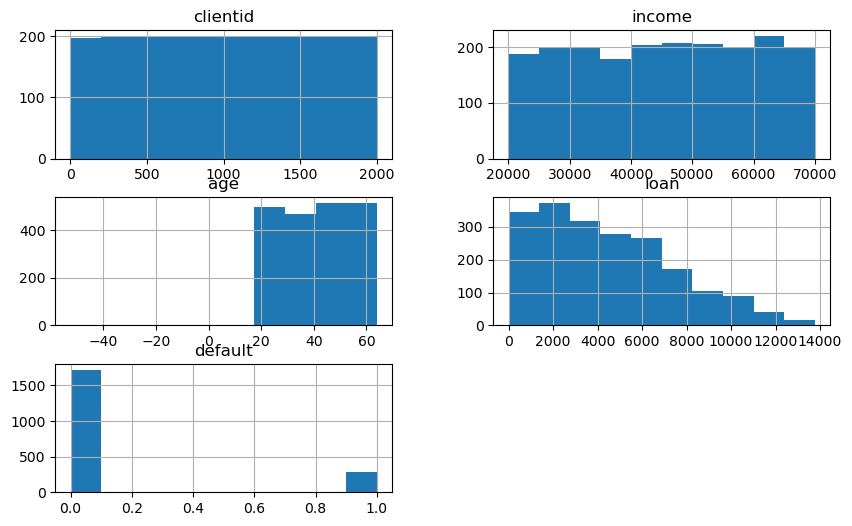

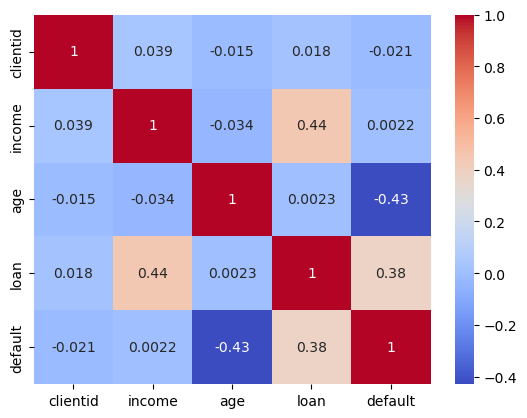

In [15]:
#Exploratory Data Analysis (EDA)
#Default Rate
df['default'].value_counts(normalize=True)
#Distribution of variables
df.hist(figsize=(10,6))
plt.show()
#Correlation Matrix
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()


In [17]:
# 5 Feature Engineering
df['debt_to_income'] = df['loan'] / df['income']

In [19]:
#Train-Test Split
train, test = train_test_split(
    df,
    test_size=0.3,
    random_state=42
)

[INFO] creating woe binning ...


C:\Users\sagni\anaconda3\Lib\site-packages\scorecardpy\condition_fun.py:131: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0 0 0 ... 0 0 0]' has dtype incompatible with int32, please explicitly cast to a compatible dtype first.
  dat.loc[:,y] = dat[y].apply(lambda x: x if pd.isnull(x) else int(x)) #dat[y].astype(int)
C:\Users\sagni\anaconda3\Lib\site-packages\scorecardpy\condition_fun.py:40: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  datetime_cols = dat.apply(pd.to_numeric,errors='ignore').select_dtypes(object).apply(pd.to_datetime,errors='ignore').select_dtypes('datetime64').columns.tolist()
C:\Users\sagni\anaconda3\Lib\site-packages\scorecardpy\condition_fun.py:40: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch

Binning on 1397 rows and 6 columns in 00:00:10


{'loan': <Figure size 640x480 with 2 Axes>,
 'clientid': <Figure size 640x480 with 2 Axes>,
 'income': <Figure size 640x480 with 2 Axes>,
 'debt_to_income': <Figure size 640x480 with 2 Axes>,
 'age': <Figure size 640x480 with 2 Axes>}

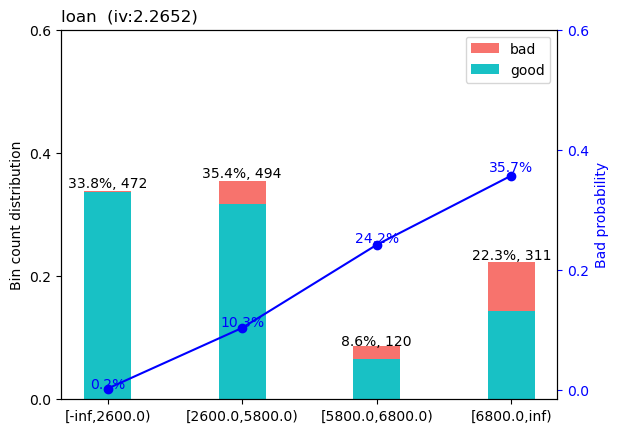

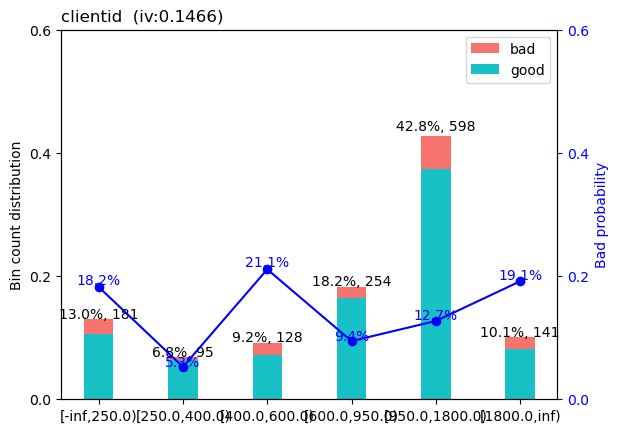

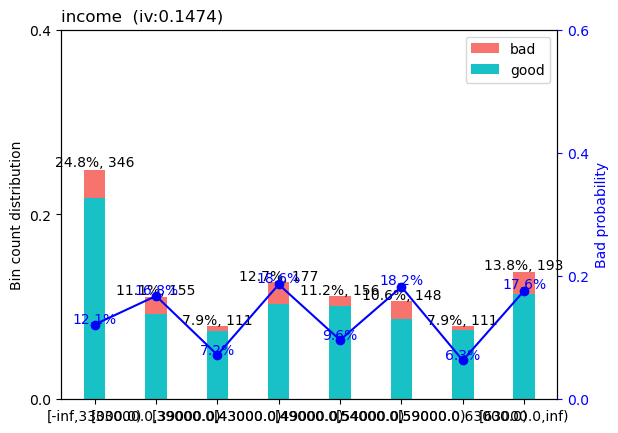

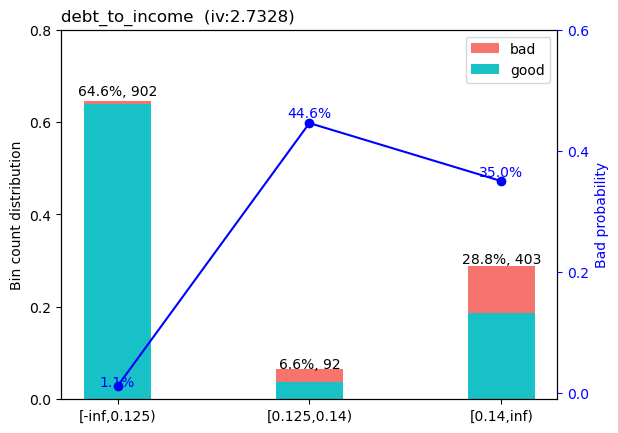

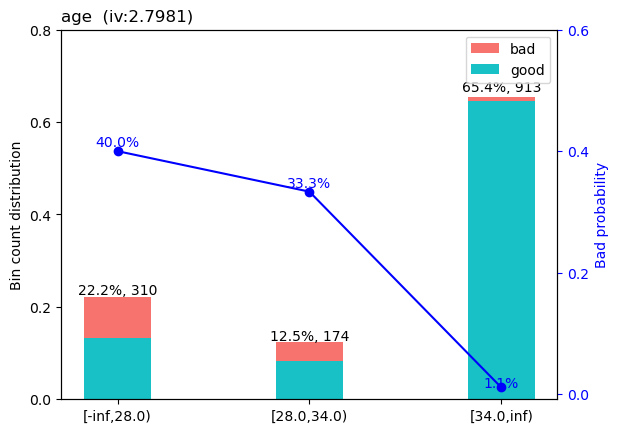

In [21]:
#6 Variable Binning (Fine Classing)
#Binning converts variables into risk groups.
bins = sc.woebin(train, y='default')
bins
sc.woebin_plot(bins)

In [23]:
#7 Weight of Evidence Transformation
#Convert features into WOE values
train_woe = sc.woebin_ply(train, bins)
test_woe = sc.woebin_ply(test, bins)
#Preview
train_woe.head()


[INFO] converting into woe values ...
[INFO] converting into woe values ...


,default,loan_woe,clientid_woe,income_woe,debt_to_income_woe,age_woe
560,0,-4.318119,0.517456,-0.718548,-2.654142,1.431274
846,0,-4.318119,-0.423286,-0.861741,-2.654142,1.431274
1653,0,1.247952,-0.090195,0.363434,1.217155,-2.666398
1347,0,-0.325005,-0.090195,0.294196,-2.654142,-2.666398
1163,0,-4.318119,-0.090195,-0.142619,-2.654142,1.143592


In [25]:
#8 Information Value (Feature Selection)
iv = sc.iv(train, y='default')

print(iv)

C:\Users\sagni\anaconda3\Lib\site-packages\scorecardpy\condition_fun.py:131: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0 0 0 ... 0 0 0]' has dtype incompatible with int32, please explicitly cast to a compatible dtype first.
  dat.loc[:,y] = dat[y].apply(lambda x: x if pd.isnull(x) else int(x)) #dat[y].astype(int)


         variable  info_value
0            loan    0.005267
4             age    0.005267
1        clientid    0.005267
2          income    0.005267
3  debt_to_income    0.005267


In [27]:
# 9 Prepare Data for PD Model
X_train = train_woe.drop(columns=['default'])
y_train = train_woe['default']

X_test = test_woe.drop(columns=['default'])
y_test = test_woe['default']

In [29]:
#10 Logistic Regression PD Model
model = LogisticRegression()

model.fit(X_train, y_train)

LogisticRegression()

In [33]:
#Generate Predictions
y_pred = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:,1]

#Confusion Matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[509   0]
 [ 11  80]]


In [35]:
#Precision, Recall, Accuracy
from sklearn.metrics import precision_score, recall_score, accuracy_score

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)

print("Precision:", precision)
print("Recall:", recall)
print("Accuracy:", accuracy)

Precision: 1.0
Recall: 0.8791208791208791
Accuracy: 0.9816666666666667


In [37]:
# Logistic Regression Anova Table
# Import libraries
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import logit
from scipy.stats import chi2

# -------------------------------
# Step 1: Add intercept to X_train
# -------------------------------
X_train_sm = sm.add_constant(X_train)

# -------------------------------
# Step 2: Fit Logistic Regression
# -------------------------------
logit_model = sm.Logit(y_train, X_train_sm)

result = logit_model.fit()

# -------------------------------
# Step 3: Print full regression output
# -------------------------------
print(result.summary())

# -------------------------------
# Step 4: Extract log-likelihood values
# -------------------------------
LL_full = result.llf
LL_null = result.llnull

# -------------------------------
# Step 5: Likelihood Ratio Test
# -------------------------------
LR_stat = -2 * (LL_null - LL_full)

df = X_train_sm.shape[1] - 1

p_value = chi2.sf(LR_stat, df)

# -------------------------------
# Step 6: Construct ANOVA Table
# -------------------------------
anova_table = pd.DataFrame({
    "Source": ["Model", "Residual"],
    "DF": [df, len(y_train) - df - 1],
    "Log-Likelihood": [LL_full, LL_null],
    "LR Statistic": [LR_stat, None],
    "p-value": [p_value, None]
})

print("\nANOVA Table (Likelihood Ratio Test)")
print(anova_table)

Optimization terminated successfully.
         Current function value: 0.068407
         Iterations 10
                           Logit Regression Results                           
Dep. Variable:                default   No. Observations:                 1397
Model:                          Logit   Df Residuals:                     1391
Method:                           MLE   Df Model:                            5
Date:                Thu, 19 Mar 2026   Pseudo R-squ.:                  0.8291
Time:                        19:41:32   Log-Likelihood:                -95.564
converged:                       True   LL-Null:                       -559.20
Covariance Type:            nonrobust   LLR p-value:                3.341e-198
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 -0.8055      0.272     -2.957      0.003      -1.340      -0.272
loan

In [39]:
#11 Predict Probability of Default
pd_train = model.predict_proba(X_train)[:,1]

pd_test = model.predict_proba(X_test)[:,1]

In [41]:
#12 Model Performance
roc_auc_score(y_test, pd_test)

0.9799542304453897

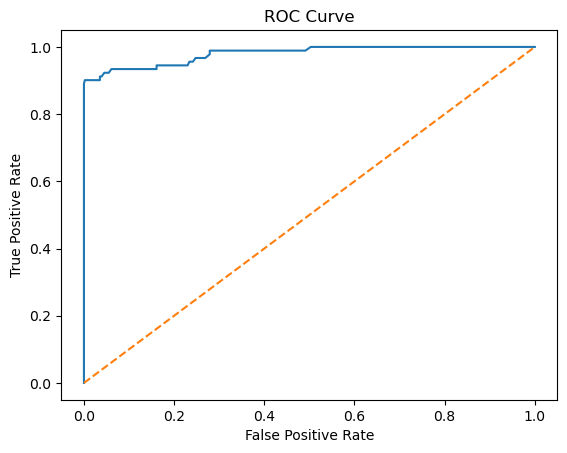

In [43]:
# 13 ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, pd_test)

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')

plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.show()

In [45]:
#14 Gini Coefficient
# Gini = 2*AUC - 1
auc = roc_auc_score(y_test, pd_test)

gini = 2*auc - 1

print("Gini:", gini)

Gini: 0.9599084608907793


C:\Users\sagni\anaconda3\Lib\site-packages\scorecardpy\condition_fun.py:131: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0
 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0
 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0
 0 0 1 0 0 0 0 1 0 1 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0
 1 0 0 0 0 1 1 0 0 0 0 0 1 0 1 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0
 0 0 0 0 0 0 1 0 0 1 0 0 0 1 1 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 1 0 0 0 0 1
 0 0 0 0 0 0 0 0 1 0 0 1 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0
 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 1 1 1 0
 0 1 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 

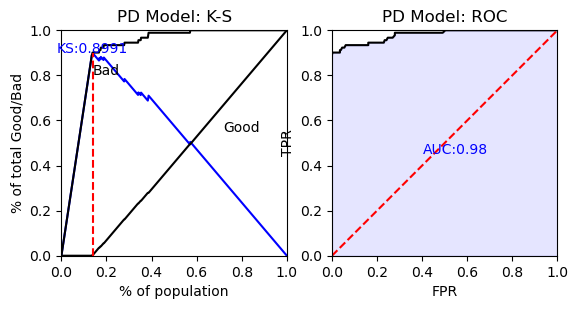

In [47]:
# 15 KS Statistic (Important for Banks)
ks = sc.perf_eva(
    y_test,
    pd_test,
    title="PD Model"
)

In [51]:
#Full Classification Report (Recommended)
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       509
           1       1.00      0.88      0.94        91

    accuracy                           0.98       600
   macro avg       0.99      0.94      0.96       600
weighted avg       0.98      0.98      0.98       600



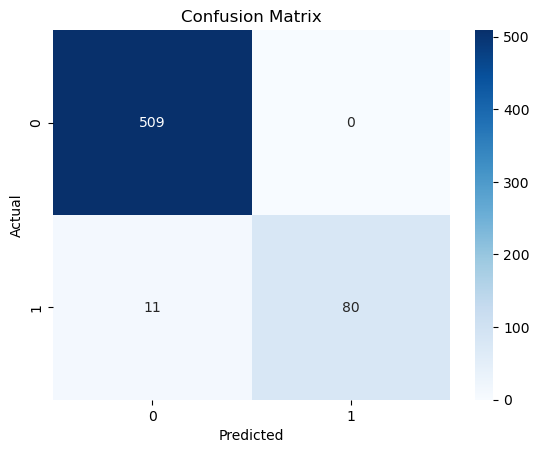

In [53]:
#Visual Confusion Matrix (Optional but Good)
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [49]:
#16 Scorecard Generation
#Now convert PD model to credit score.
card = sc.scorecard(bins, model, X_train.columns)
card

{'basepoints':      variable  bin  points
 0  basepoints  NaN   451.0,
 'loan':   variable              bin  points
 0     loan    [-inf,2600.0)   140.0
 1     loan  [2600.0,5800.0)    11.0
 2     loan  [5800.0,6800.0)   -22.0
 3     loan     [6800.0,inf)   -40.0,
 'clientid':    variable             bin  points
 4  clientid    [-inf,250.0)   -16.0
 5  clientid   [250.0,400.0)    52.0
 6  clientid   [400.0,600.0)   -25.0
 7  clientid   [600.0,950.0)    21.0
 8  clientid  [950.0,1800.0)     4.0
 9  clientid    [1800.0,inf)   -19.0,
 'income':    variable                bin  points
 10   income     [-inf,33000.0)     5.0
 11   income  [33000.0,39000.0)    -9.0
 12   income  [39000.0,43000.0)    26.0
 13   income  [43000.0,49000.0)   -13.0
 14   income  [49000.0,54000.0)    15.0
 15   income  [54000.0,59000.0)   -12.0
 16   income  [59000.0,63000.0)    31.0
 17   income      [63000.0,inf)   -11.0,
 'debt_to_income':           variable           bin  points
 18  debt_to_income  [-inf,0.125

In [57]:
#Standardize Scorecard Between 300–900
# Min-Max Scalling for Standarizasion
# Generate scorecard
card = sc.scorecard(bins, model, X_train.columns)

# Apply scorecard
test_score = sc.scorecard_ply(test, card)

In [43]:
#17 Calculate Credit Scores
train_score = sc.scorecard_ply(train, card)

test_score = sc.scorecard_ply(test, card)
test_score[['score']].head()

,score
259,686.0
355,707.0
301,175.0
584,1218.0
1289,637.0


In [59]:
#18 Expected Loss Calculation
# EL= PD×LGD×EAD
#Assume LGD
LGD = 0.6
#EAD ≈ loan amount
test_score = test_score.reset_index(drop=True)
test = test.reset_index(drop=True)

test_score['PD'] = pd_test
test_score['EAD'] = test['loan']
test_score['LGD'] = LGD

test_score['Expected_Loss'] = (
    test_score['PD'] *
    test_score['LGD'] *
    test_score['EAD']
)

In [63]:
#NOW Standardize Score (300–900)
min_score = test_score['score'].min()
max_score = test_score['score'].max()

test_score['Score_300_900'] = 300 + (
    (test_score['score'] - min_score) /
    (max_score - min_score)
) * (900 - 300)

test_score['Score_300_900'] = test_score['Score_300_900'].astype(int)

In [ ]:
# 19 Final Output
test_score[['score','Score_300_900']].head()

,score,Score_300_900
0,686.0,603
1,707.0,612
2,175.0,363
3,1218.0,852
4,637.0,580


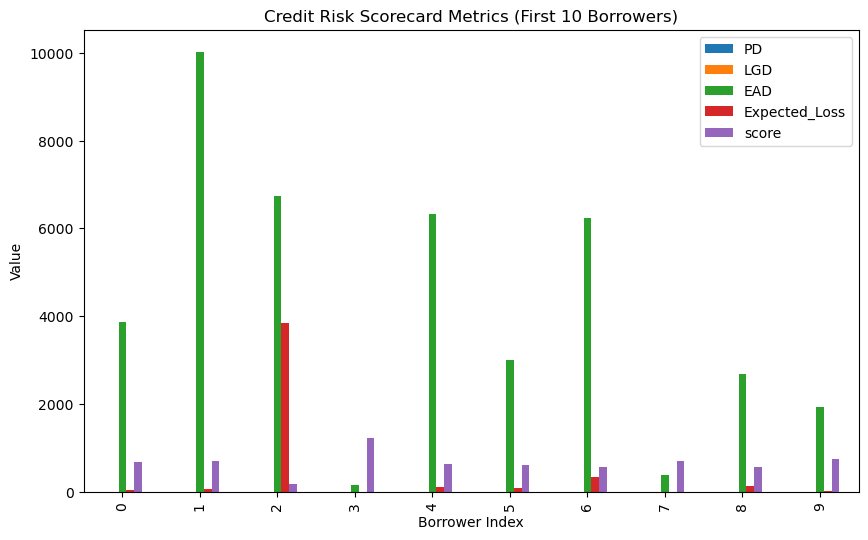

In [53]:
# 20 Bar Graph
import matplotlib.pyplot as plt

# Select first 10 rows
plot_data = test_score[['PD','LGD','EAD','Expected_Loss','score']].head(10)

plot_data.plot(kind='bar', figsize=(10,6))

plt.title("Credit Risk Scorecard Metrics (First 10 Borrowers)")
plt.xlabel("Borrower Index")
plt.ylabel("Value")

plt.legend()
plt.show()